## 1. Compare Portfolios

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
spy_returns = pd.read_csv('data/spy_returns.csv', index_col = 0, parse_dates = True).reindex(t_eval)
benchmark = (1 + spy_returns.reindex(t_eval)).cumprod()

In [4]:
factor_returns = pd.read_csv('outputs/factor_returns.csv', index_col = 0, parse_dates = True)
ra_returns = pd.read_csv('outputs/ra_returns.csv', index_col = 0, parse_dates = True)



factor_portfolio = (1 + factor_returns).cumprod()
ra_portfolio = (1 + ra_returns).cumprod()


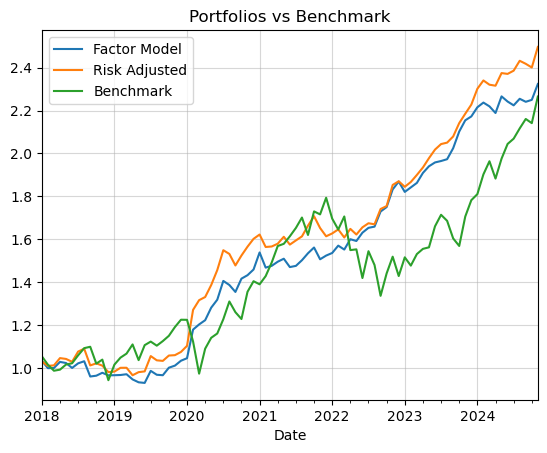

In [5]:
fig, ax = plt.subplots()

factor_portfolio.squeeze().plot(ax=ax, label='Factor Model')
ra_portfolio.squeeze().plot(ax=ax, label='Risk Adjusted')
benchmark.squeeze().plot(ax=ax, label='Benchmark')

ax.set_title('Portfolios vs Benchmark')
ax.grid(alpha=0.5)
ax.legend()

plt.savefig("outputs/Portfolios_vs_Benchmark.png")

In [6]:
mvo_returns = np.load('outputs/mvo_returns_lambda.npy', allow_pickle = True).item()
lams = np.arange(1,50,1)

mvo_portfolios = {}
for lam in lams:
    mvo_portfolios[lam] = (1 + mvo_returns[lam]).cumprod()



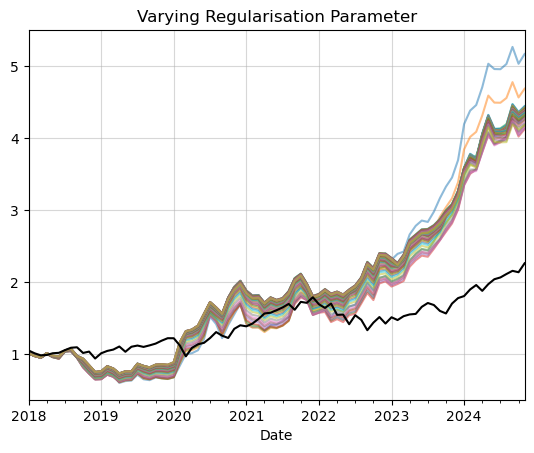

In [7]:
fig, ax = plt.subplots()

for lam in lams:
    mvo_portfolios[lam].plot(ax = ax, alpha = 0.5, label = rf'$\lambda$ = {lam}')

benchmark.squeeze().plot(ax=ax, color = 'black', label='Benchmark')
ax.set_title('Varying Regularisation Parameter')
#ax.legend()
ax.grid(alpha = 0.5)
plt.savefig('outputs/Varying Regularisation Parameter.png')

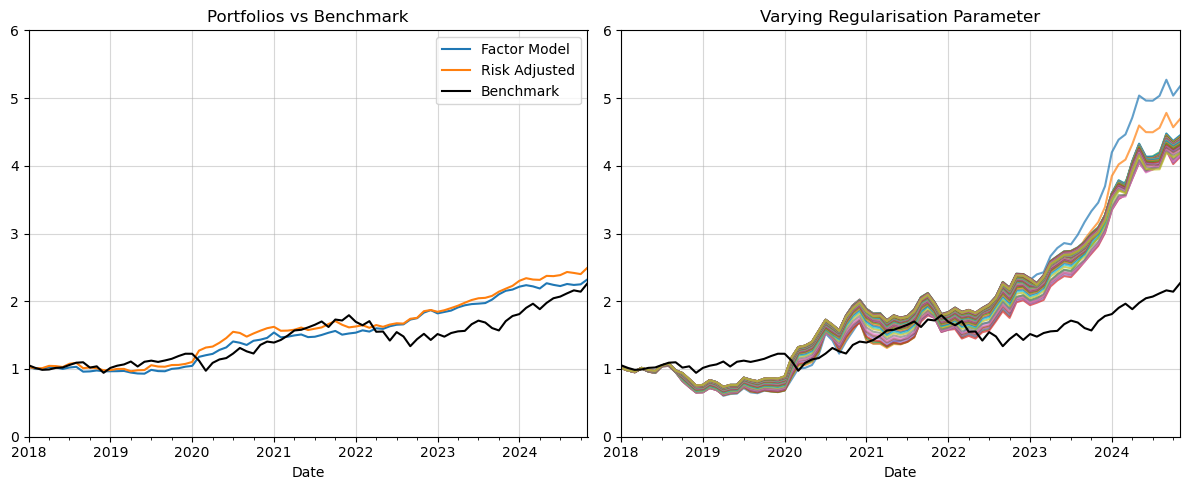

In [8]:
fig, ax = plt.subplots(1,2, figsize = (12,5), sharey = True)

factor_portfolio.squeeze().plot(ax=ax[0], label='Factor Model')
ra_portfolio.squeeze().plot(ax=ax[0], label='Risk Adjusted')
benchmark.squeeze().plot(ax=ax[0], color = 'black', label='Benchmark')

ax[0].set_title('Portfolios vs Benchmark')
ax[0].grid(alpha=0.5)
ax[0].legend()

for lam in lams:
    mvo_portfolios[lam].plot(ax = ax[1], alpha = 0.7, label = rf'$\lambda$ = {lam}')

benchmark.squeeze().plot(ax=ax[1], color = 'black', label='Benchmark')
ax[1].set_title('Varying Regularisation Parameter')
#ax[1].legend()
ax[1].grid(alpha = 0.5)
ax[1].tick_params(axis='y', labelleft=True)
ax[1].set_yticks(ax[0].get_yticks())

plt.tight_layout()
plt.savefig('outputs/portfolios.png')

In [9]:
performance_df = pd.DataFrame(columns = ['Lambda', 'Final Value'])
for lam, portfolio in mvo_portfolios.items():
    performance_df.loc[lam] = [lam, portfolio.iloc[-1]]

performance_df.set_index('Lambda', inplace = True)
performance_df.sort_values('Final Value', ascending = False)

,Final Value
Lambda,
1.0,5.172168
2.0,4.689968
20.0,4.448287
21.0,4.445927
19.0,4.439057
18.0,4.430881
22.0,4.427188
17.0,4.421356
16.0,4.410104


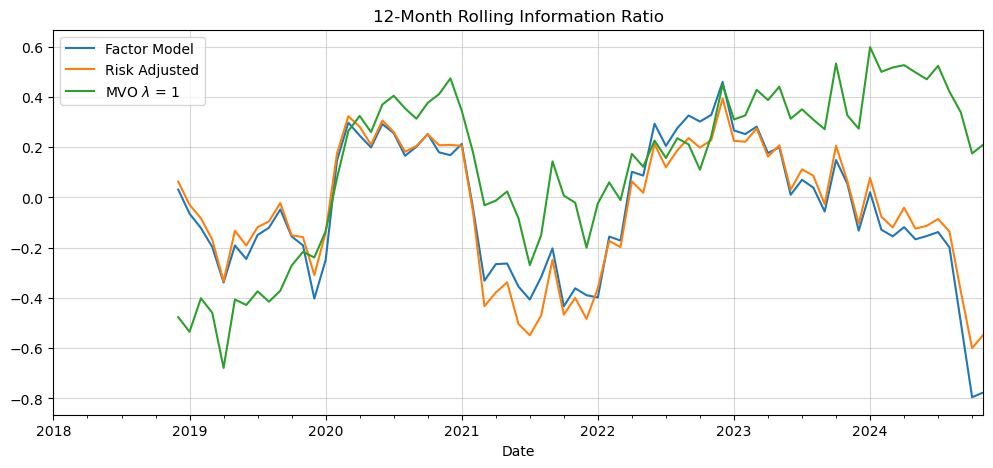

In [16]:
# Rolling IR = rolling excessive returns (mean) / rolling excessive volatility (std)

def rolling_IR(returns, benchmark_returns = spy_returns, window = 12):
    excess_returns = returns.squeeze() - benchmark_returns.squeeze()
    rolling_mean = excess_returns.rolling(window).mean()
    rolling_std = excess_returns.rolling(window).std()
    rolling_ir = rolling_mean / rolling_std
    return rolling_ir

fig, ax = plt.subplots(figsize = (12,5))
rolling_IR((factor_returns), window=12).plot(ax = ax, label = 'Factor Model')
rolling_IR((ra_returns), window=12).plot(ax = ax, label = 'Risk Adjusted')
rolling_IR((mvo_returns[1]), window=12).plot(ax = ax, label = r'MVO $\lambda$ = 1')
ax.set_title('12-Month Rolling Information Ratio')
ax.legend()
ax.grid(alpha = 0.5)


plt.savefig('outputs/rolling_IR.png')


## 2. Portfolio Analytics

In [11]:
def analyse_portfolio(portfolio_returns, outs = False):

    if isinstance(portfolio_returns, pd.Series):
        portfolio_returns = portfolio_returns.to_frame()
        
    mean = portfolio_returns.mean().item()
    std = portfolio_returns.std().item()
    sharpe = np.sqrt(12) * mean / std

    portfolio = (1 + portfolio_returns).cumprod()
    total_return = portfolio.iloc[-1].item() - 1
    annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
    running_max = portfolio.cummax()
    drawdown = portfolio / running_max - 1
    max_dd = drawdown.min().item()

    if outs:
        return mean, std, sharpe, total_return, annual_return, max_dd
    
    else:
        print(f"Mean Return: {mean * 100:.2f}%")
        print(f"Mean Std: {std * 100:.2f}%")
        print(f"Sharpe Ratio: {sharpe:.2f}")
        print(f"Total Returns: {total_return * 100:.0f}%")
        print(f"Annual Return: {annual_return * 100:.0f}%")
        print(f"Max drawdown: {max_dd * 100:.0f}%")

    


In [12]:
print('factor model')
analyse_portfolio(factor_returns)
print()

print('risk-adjusted model')
analyse_portfolio(ra_returns)
print()

print(rf'mean-variance optimised model ($\lambda = 1$)')
analyse_portfolio(mvo_returns[1])
print()



factor model
Mean Return: 1.06%
Mean Std: 2.67%
Sharpe Ratio: 1.37
Total Returns: 132%
Annual Return: 13%
Max drawdown: -10%

risk-adjusted model
Mean Return: 1.15%
Mean Std: 2.86%
Sharpe Ratio: 1.39
Total Returns: 150%
Annual Return: 14%
Max drawdown: -11%

mean-variance optimised model ($\lambda = 1$)
Mean Return: 2.34%
Mean Std: 8.49%
Sharpe Ratio: 0.96
Total Returns: 417%
Annual Return: 27%
Max drawdown: -43%



## 3. Efficient Frontier

NameError: name 'frontier_x' is not defined

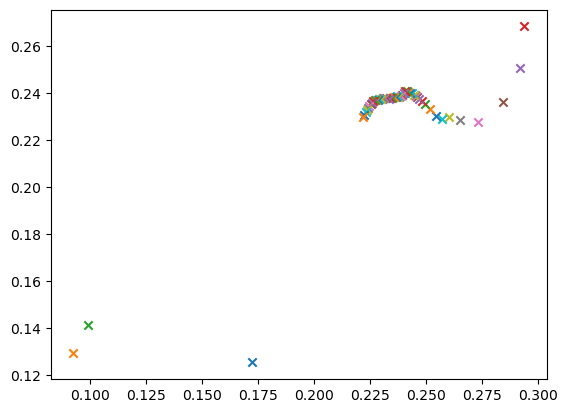

In [13]:

portfolios = [spy_returns, factor_returns, ra_returns]
labels = ['spy_returns', 'factor_returns', 'ra_returns']

fig, ax = plt.subplots()

for returns, label in zip(portfolios, labels):
    _, std, _, _, ann, _ = analyse_portfolio(returns, outs = True)
    ax.scatter(np.sqrt(12) * std, ann, marker = 'x', label = label)

for lam in lams:
    _, std, _, _, ann, _ = analyse_portfolio(mvo_returns[lam], outs = True)
    ax.scatter(np.sqrt(12) * std, ann, marker = 'x', label = rf'$\lambda$ = {lam}')

#frontier_x = np.sqrt(12) * np.array([0, 265, 687, 910]) / 10000
#frontier_y = np.array([7.4, 14,24.5,28]) / 100

ax.plot(frontier_x, frontier_y, color = 'b', ls = '--', alpha = 0.7, label = 'Efficient Frontier')
ax.set_xlabel('Volatility')
ax.set_ylabel('Annualised Return')
ax.set_xlim(0,0.4)
ax.set_ylim(0,0.3)
ax.set_title('Risk vs Return')
ax.grid(alpha = 0.5)
ax.legend()

plt.savefig('outputs/Efficient Frontier.png')

In [ ]:
analyse_portfolio(mvo_returns[30])


Mean Return: 1.05%
Mean Std: 2.67%
Sharpe Ratio: 1.36
Total Returns: 132%
Annual Return: 13%
Max drawdown: -10%
Mean Return: 2.06%
Mean Std: 6.87%
Sharpe Ratio: 1.04
Total Returns: 354%
Annual Return: 24%
Max drawdown: -33%
Mean Return: 2.48%
Mean Std: 9.10%
Sharpe Ratio: 0.94
Total Returns: 458%
Annual Return: 28%
Max drawdown: -41%
